<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png"
         width="500"/>
</p>

<h2 align="center"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="center"><i>Quantitative Finance</i></h2>
<h2 align="center"><i>Prof. Luis Carlos Alvarado Garnica</i></h2>

# The Heston Model — European Call Pricing
---
Implementacion paso a paso del pricing de un call europeo bajo Heston:

$$\text{SDEs de Heston} \;\xrightarrow{\text{Feynman-Kac + forma propuesta}}\;
\varphi_j(u) \;\xrightarrow{\text{Inversion de Fourier}}\;
P_1, P_2 \;\longrightarrow\; C = S_t P_1 - Ke^{-r\\tau}P_2$$

**Referencia:** Heston (1993); forma estable: Albrecher et al. (2007) *The Little Heston Trap.*


## Librerias

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f9f9f9',
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'lines.linewidth'  : 2,
})

PURPLE = '#534AB7'
GREEN  = '#1D9E75'
ORANGE = '#D85A30'
AMBER  = '#BA7517'
BLUE   = '#2A7FBF'


## 1. Parametros

| Parametro | Simbolo | Valor | Significado |
|-----------|---------|-------|-------------|
| Precio spot | $S_0$ | 100 | Precio actual del activo |
| Strike | $K$ | 100 | Precio de ejercicio (ATM) |
| Tasa libre de riesgo | $r$ | 5% | Continua, anualizada |
| Madurez | $\tau$ | 1 año | Tiempo al vencimiento |
| Varianza inicial | $v_0$ | 0.04 | Vol inicial = 20% |
| Velocidad de reversion | $\kappa$ | 2.0 | Rapidez con que $v_t$ regresa a $\theta$ |
| Varianza de largo plazo | $\theta$ | 0.04 | Vol largo plazo |
| Vol de la vol | $\xi$ | 0.30 | Cuanto fluctua la varianza |
| Correlacion | $\rho$ | -0.70 | Efecto leverage (skew negativo) |

`Nota: el parámetro de varianza es 0.04, porque es el cuadrado de la volatilidad inicial (20%).`


In [2]:
# Parametros de mercado
S0  = 100.0
K   = 100.0
r   = 0.05
tau = 1.0

# Parametros de Heston
v0    = 0.04
kappa = 2.0
theta = 0.04
xi    = 0.30
rho   = -0.70

sigma_bs = np.sqrt(theta)   # volatilidad B&S de referencia (20%)

print(f"Volatilidad B&S de referencia : {sigma_bs:.1%}")
feller = 2*kappa*theta > xi**2
print(f"Condicion de Feller 2*kappa*theta > xi^2 : {2*kappa*theta:.3f} > {xi**2:.3f}",
      "OK" if feller else "VIOLADA (v puede tocar cero)")


Volatilidad B&S de referencia : 20.0%
Condicion de Feller 2*kappa*theta > xi^2 : 0.160 > 0.090 OK


```
Nota de la condición de Feller: El hecho de que se viole Feller, no invalida el modelo, solo requiere más cuidado numérico en Monte Carlo. (Veremos los usos de Monte Carlo la siguiente semana)
```

## 2. Black-Scholes (referencia)

$$C_{BS} = S_0\,\mathcal{N}(d_1) - Ke^{-r\\tau}\,\mathcal{N}(d_2)$$


La función de 

```
bs_implied_vol
```

lo que hace es calcular la volatilidad implícita de un call europeo bajo Black-Scholes, dado el precio del call y los parámetros del modelo.

No lo vimos detalladamente en clase, solamente hice un dibujo en el pizarrón. La idea es encontrar la volatilidad implícita que hace que el precio del call bajo Black-Scholes sea igual al precio del call observado en el mercado.

$$C_{market}(K,T) = C_{BS}(S_0, K, r, T, \sigma_{imp}(K,T))$$

La función utiliza el método de Newton-Raphson para encontrar la raíz de la ecuación que relaciona el precio del call con la volatilidad implícita.

In [3]:
def bs_call(S, K, r, tau, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return S*norm.cdf(d1) - K*np.exp(-r*tau)*norm.cdf(d2), norm.cdf(d1), norm.cdf(d2)


def bs_implied_vol(price, S, K, r, tau, tol=1e-7):
    intrinsic = max(S - K*np.exp(-r*tau), 0.0)
    if price <= intrinsic + 1e-8:
        return np.nan
    lo, hi = 1e-6, 5.0
    for _ in range(200):
        mid = (lo + hi) / 2.0
        diff = bs_call(S, K, r, tau, mid)[0] - price
        if abs(diff) < tol:
            return mid
        lo, hi = (mid, hi) if diff < 0 else (lo, mid)
    return mid


## 3. Funcion Caracteristica de Heston (forma estable)

$$\varphi_j(u) = e^{C_j + D_j v + iux}$$

Cantidades auxiliares (slide *Auxiliary Quantities*):

$$d_j = \\sqrt{(\\rho\\xi\,iu - b_j)^2 + \\xi^2(u^2 - 2u_j\,iu)}
\\qquad
g_{2j} = \\frac{b_j - \\rho\\xi\,iu + d_j}{b_j - \\rho\\xi\,iu - d_j}$$

| | $u_j$ | $b_j$ |
|--|--|--|
| $j=1$ ($P_1$, medida accion) | $+1/2$ | $\\kappa - \\rho\\xi$ |
| $j=2$ ($P_2$, medida riesgo-neutral) | $-1/2$ | $\\kappa$ |


In [4]:
def heston_cf_j(u, j, x, v, tau, r, kappa, theta, xi, rho):
    """
    Funcion caracteristica de Heston phi_j(u) -- forma estable (Little Trap).
    j=1 -> medida accion (P1),  j=2 -> medida riesgo-neutral (P2).
    """
    i  = 1j
    uj = 0.5             if j == 1 else -0.5
    bj = kappa - rho*xi  if j == 1 else  kappa

    # Cantidades auxiliares
    dj  = np.sqrt((rho*xi*i*u - bj)**2 + xi**2*(u**2 - 2*uj*i*u))
    g2j = (bj - rho*xi*i*u + dj) / (bj - rho*xi*i*u - dj)

    # Solucion de las ODEs (slide: Solving for D / Solving for C)
    Dj = ((bj - rho*xi*i*u + dj) / xi**2) *          ((1 - np.exp(dj*tau)) / (1 - g2j*np.exp(dj*tau)))

    Cj = r*i*u*tau + (kappa*theta/xi**2) * (
            (bj - rho*xi*i*u + dj)*tau
            - 2*np.log((1 - g2j*np.exp(dj*tau)) / (1 - g2j)))

    # Forma propuesta: phi = exp[C + D*v + i*u*x]
    return np.exp(Cj + Dj*v + i*u*x)


## 4. Inversion de Fourier -> $P_1$ y $P_2$

$$P_j = \frac{1}{2} + \frac{1}{\pi}
\int_0^{\infty} \operatorname{Re}\!\left[
\frac{e^{-iu\ln K}\,\varphi_j(u)}{iu}
\right]du$$


Esta es la inversa de Fourier de la función característica de Heston, que nos permite calcular las probabilidades $P_1$ y $P_2$ necesarias para el pricing del call europeo.

Nos quedamos únicamente con la parte real de la integral, ya que el precio del call es una cantidad real.

In [5]:
def heston_prob_j(j, x, v, tau, K, r, kappa, theta, xi, rho):
    """Probabilidad P_j via inversion de Fourier (Gil-Pelaez, 1951)."""
    lnK = np.log(K)
    def integrand(u):
        phi = heston_cf_j(u, j, x, v, tau, r, kappa, theta, xi, rho)
        return np.real(np.exp(-1j*u*lnK) * phi / (1j*u))  #np.real se queda con la parte real de la integral
    val, _ = quad(integrand, 1e-8, 500, limit=300)
    return 0.5 + val / np.pi

def heston_call(S, K, r, tau, v0, kappa, theta, xi, rho):
    """Precio de call europeo bajo Heston: C = S*P1 - K*exp(-r*tau)*P2"""
    x  = np.log(S)
    P1 = heston_prob_j(1, x, v0, tau, K, r, kappa, theta, xi, rho)
    P2 = heston_prob_j(2, x, v0, tau, K, r, kappa, theta, xi, rho)
    return S*P1 - K*np.exp(-r*tau)*P2, P1, P2


## 5. Comparacion puntual: B&S vs Heston (call ATM)

In [6]:
bs_price, Nd1, Nd2 = bs_call(S0, K, r, tau, sigma_bs)
h_price,  P1,  P2  = heston_call(S0, K, r, tau, v0, kappa, theta, xi, rho)

print("=" * 52)
print(f"  {'':20s}  {'Black-Scholes':>12}  {'Heston':>10}")
print("=" * 52)
print(f"  {'Precio del call':20s}  {bs_price:>12.4f}  {h_price:>10.4f}")
print(f"  {'P1  /  N(d1)':20s}  {Nd1:>12.4f}  {P1:>10.4f}")
print(f"  {'P2  /  N(d2)':20s}  {Nd2:>12.4f}  {P2:>10.4f}")
print("=" * 52)
print(f"  Diferencia Heston - B&S  :  {h_price - bs_price:+.4f}")


                        Black-Scholes      Heston
  Precio del call            10.4506     10.3942
  P1  /  N(d1)                0.6368      0.6919
  P2  /  N(d2)                0.5596      0.6181
  Diferencia Heston - B&S  :  -0.0564


## 6. Visualizacion 1 - Precio del call vs Strike

Se generan 35 strikes equiespaciados entre 70 y 135, y se calcula el precio del call bajo Heston y Black-Scholes para cada strike. Luego, se grafican ambos precios en función del strike.

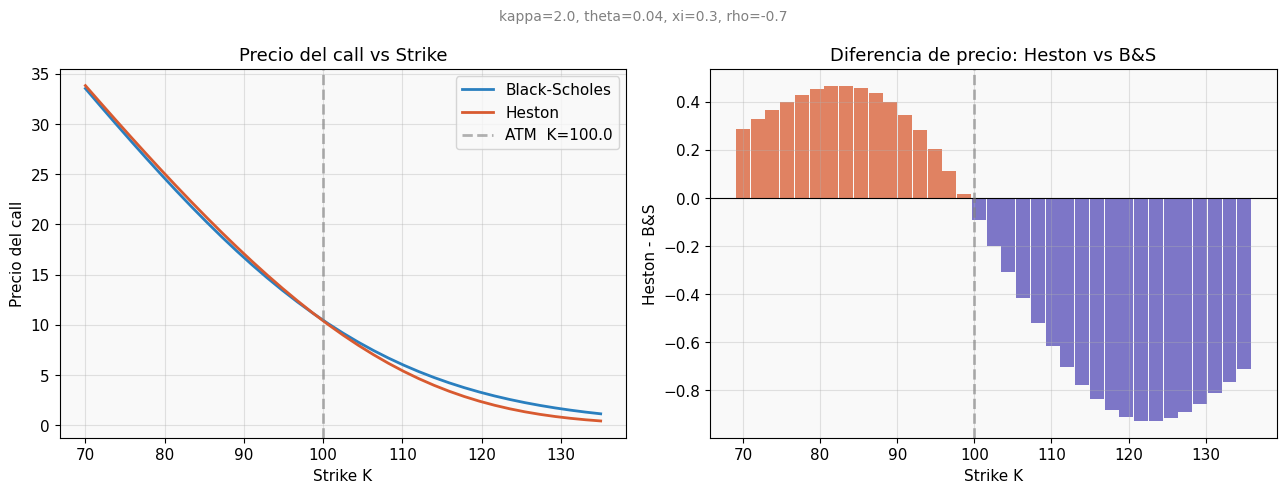

In [7]:
strikes = np.linspace(70, 135, 35)

prices_bs = np.array([bs_call(S0, k, r, tau, sigma_bs)[0] for k in strikes])
prices_h  = []
for k in strikes:
    p, _, _ = heston_call(S0, k, r, tau, v0, kappa, theta, xi, rho)
    prices_h.append(p)
prices_h = np.array(prices_h)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(strikes, prices_bs, color=BLUE,   lw=2, label='Black-Scholes')
ax.plot(strikes, prices_h,  color=ORANGE, lw=2, label='Heston')
ax.axvline(K, color='gray', ls='--', alpha=0.6, label=f'ATM  K={K}')
ax.set_xlabel('Strike K');  ax.set_ylabel('Precio del call')
ax.set_title('Precio del call vs Strike');  ax.legend()

ax = axes[1]
diff = prices_h - prices_bs
ax.bar(strikes, diff, width=1.8,
       color=[ORANGE if d > 0 else PURPLE for d in diff], alpha=0.75)
ax.axhline(0, color='black', lw=0.8);  ax.axvline(K, color='gray', ls='--', alpha=0.6)
ax.set_xlabel('Strike K');  ax.set_ylabel('Heston - B&S')
ax.set_title('Diferencia de precio: Heston vs B&S')

plt.suptitle(f'kappa={kappa}, theta={theta}, xi={xi}, rho={rho}', fontsize=10, color='gray')
plt.tight_layout();  plt.show()


## 7. Visualizacion 2 - Sonrisa de volatilidad implicita

**Este es el grafico clave.** B&S produce una $\sigma_{imp}$ plana. Heston produce el skew que se observa en el mercado real.


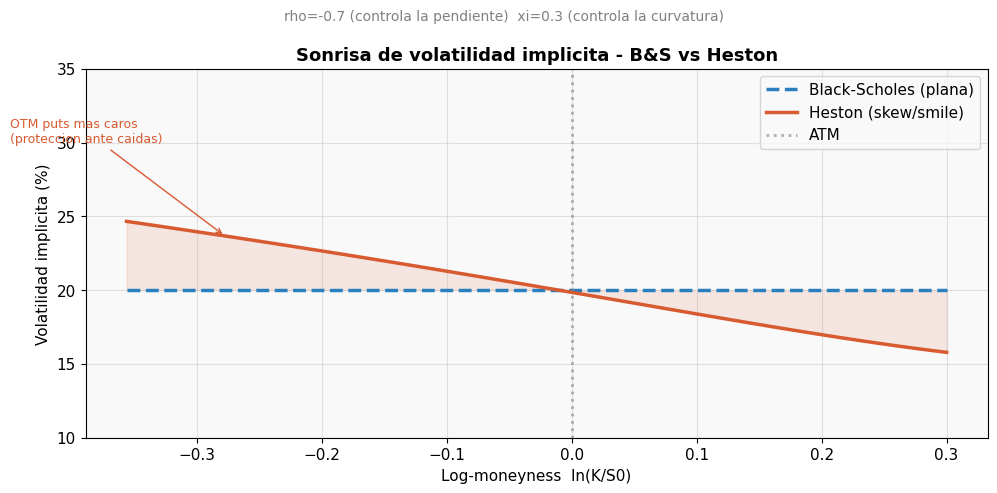

In [8]:
logm      = np.log(strikes / S0)
ivols_bs  = np.full(len(strikes), sigma_bs)
ivols_h   = np.array([bs_implied_vol(p, S0, k, r, tau)
                       for p, k in zip(prices_h, strikes)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(logm, ivols_bs*100, color=BLUE,   lw=2.5, ls='--', label='Black-Scholes (plana)')
ax.plot(logm, ivols_h*100,  color=ORANGE, lw=2.5,           label='Heston (skew/smile)')
ax.fill_between(logm, ivols_bs*100, ivols_h*100, alpha=0.12, color=ORANGE)
ax.axvline(0, color='gray', ls=':', alpha=0.6, label='ATM')
ax.set_xlabel('Log-moneyness  ln(K/S0)')
ax.set_ylabel('Volatilidad implicita (%)')
ax.set_title('Sonrisa de volatilidad implicita - B&S vs Heston', fontweight='bold')
ax.legend();  ax.set_ylim(10, 35)
ax.annotate('OTM puts mas caros\n(proteccion ante caidas)',
            xy=(logm[3], ivols_h[3]*100), xytext=(-0.45, 30),
            arrowprops=dict(arrowstyle='->', color=ORANGE), color=ORANGE, fontsize=9)
plt.suptitle(f'rho={rho} (controla la pendiente)  xi={xi} (controla la curvatura)',
             fontsize=10, color='gray')
plt.tight_layout();  plt.show()


## 8. Visualizacion 3 - La funcion caracteristica $\varphi_2(u)$

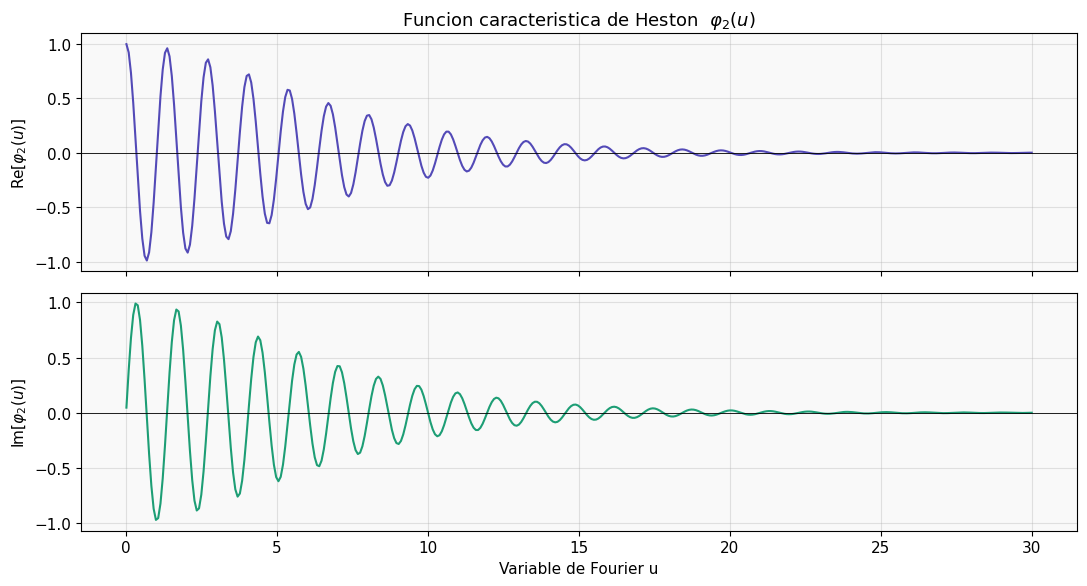

In [9]:
us       = np.linspace(0.01, 30, 400)
x_log   = np.log(S0)
phi_vals = np.array([heston_cf_j(u, 2, x_log, v0, tau, r, kappa, theta, xi, rho)
                     for u in us])

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(us, phi_vals.real, color=PURPLE, lw=1.5)
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_ylabel(rf'Re[$\varphi_2(u)$]')
axes[0].set_title(rf'Funcion caracteristica de Heston  $\varphi_2(u)$')
axes[1].plot(us, phi_vals.imag, color=GREEN,  lw=1.5)
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_ylabel(rf'Im[$\varphi_2(u)$]');  axes[1].set_xlabel('Variable de Fourier u')
plt.tight_layout();  plt.show()


## 9. Visualizacion 4 - $P_1, P_2$ vs $\mathcal{N}(d_1), \mathcal{N}(d_2)$

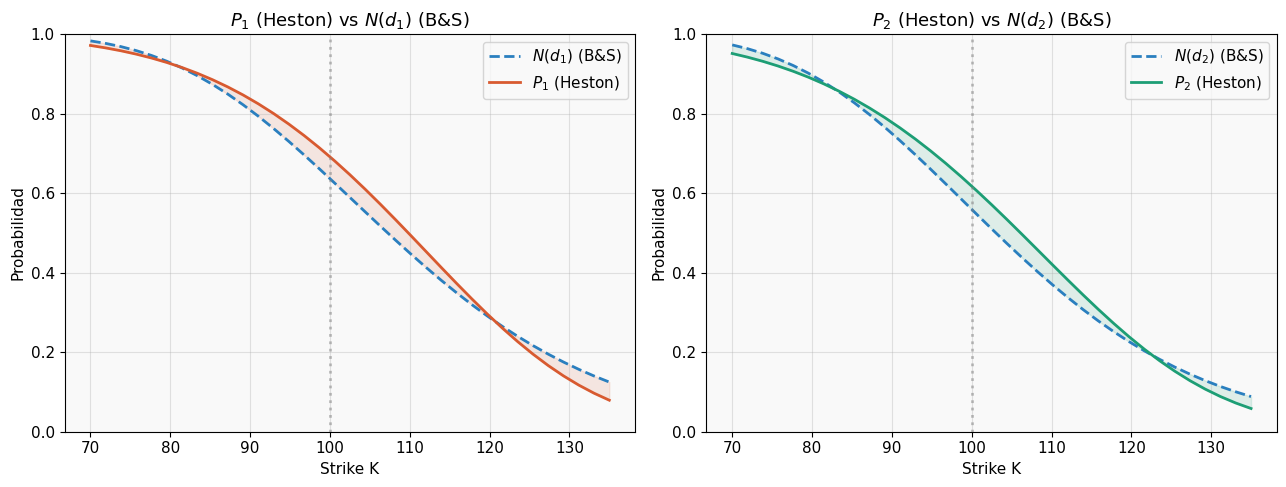

In [10]:
p1v=[]; p2v=[]; nd1v=[]; nd2v=[]
for k in strikes:
    _, p1, p2 = heston_call(S0, k, r, tau, v0, kappa, theta, xi, rho)
    _, nd1, nd2 = bs_call(S0, k, r, tau, sigma_bs)
    p1v.append(p1); p2v.append(p2); nd1v.append(nd1); nd2v.append(nd2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, hv, bv, lbl, col in [
        (axes[0], p1v, nd1v, (rf'$P_1$ (Heston)', rf'$N(d_1)$ (B&S)'), ORANGE),
        (axes[1], p2v, nd2v, (rf'$P_2$ (Heston)', rf'$N(d_2)$ (B&S)'), GREEN)]:
    ax.plot(strikes, bv, color=BLUE, lw=2, ls='--', label=lbl[1])
    ax.plot(strikes, hv, color=col,  lw=2,           label=lbl[0])
    ax.fill_between(strikes, bv, hv, alpha=0.12, color=col)
    ax.axvline(K, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('Strike K');  ax.set_ylabel('Probabilidad')
    ax.set_title(f'{lbl[0]} vs {lbl[1]}');  ax.legend();  ax.set_ylim(0, 1)
plt.tight_layout();  plt.show()


## 10. Visualizacion 5 - Efecto de $\rho$ en el skew

$\rho$ controla la **pendiente** de la sonrisa.


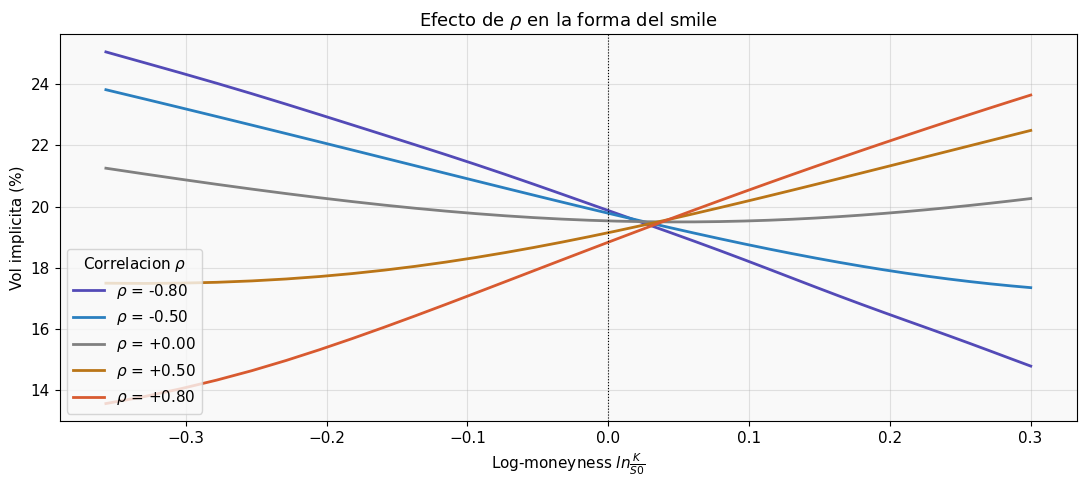

In [11]:
rhos   = [-0.80, -0.50, 0.0, 0.50, 0.80]
colors = [PURPLE, BLUE, 'gray', AMBER, ORANGE]

fig, ax = plt.subplots(figsize=(11, 5))
for rho_i, col in zip(rhos, colors):
    ivs = []
    for k in strikes:
        p, _, _ = heston_call(S0, k, r, tau, v0, kappa, theta, xi, rho_i)
        ivs.append(bs_implied_vol(p, S0, k, r, tau))
    ax.plot(logm, np.array(ivs)*100, color=col, lw=2, label=rf'$\rho$ = {rho_i:+.2f}')
ax.axvline(0, color='black', ls=':', lw=0.8)
ax.set_xlabel(rf'Log-moneyness $ln\frac{{K}}{{S0}}$');  ax.set_ylabel('Vol implicita (%)')
ax.set_title(rf'Efecto de $\rho$ en la forma del smile');  ax.legend(title=rf'Correlacion $\rho$')
plt.tight_layout();  plt.show()


## 11. Visualizacion 6 - Efecto de $\xi$ en la curvatura

$\xi$ (vol de la vol) controla la **curvatura** de la sonrisa.


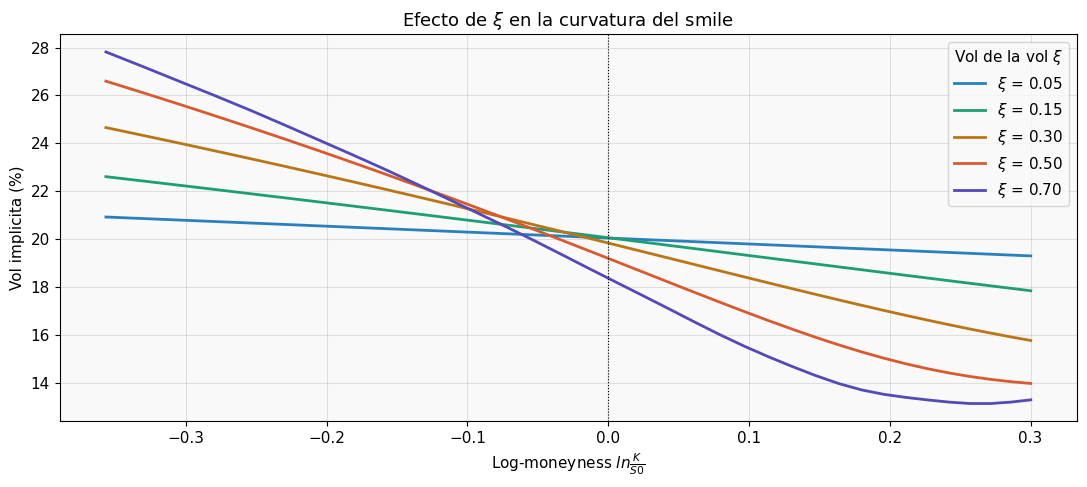

In [12]:
xis    = [0.05, 0.15, 0.30, 0.50, 0.70]
colors = [BLUE, GREEN, AMBER, ORANGE, PURPLE]

fig, ax = plt.subplots(figsize=(11, 5))
for xi_i, col in zip(xis, colors):
    ivs = []
    for k in strikes:
        p, _, _ = heston_call(S0, k, r, tau, v0, kappa, theta, xi_i, rho)
        ivs.append(bs_implied_vol(p, S0, k, r, tau))
    ax.plot(logm, np.array(ivs)*100, color=col, lw=2, label=rf'$\xi$ = {xi_i:.2f}')
ax.axvline(0, color='black', ls=':', lw=0.8)
ax.set_xlabel(rf'Log-moneyness $ln\frac{{K}}{{S0}}$');  ax.set_ylabel('Vol implicita (%)')
ax.set_title(rf'Efecto de $\xi$ en la curvatura del smile');  ax.legend(title=rf'Vol de la vol $\xi$')
plt.tight_layout();  plt.show()


## 12. Visualizacion 7 - Superficie de volatilidad implicita

Volatilidad implicita como funcion de (Strike, Madurez).
Esta es la superficie que se usa para calibrar el modelo al mercado.

`Nota: en el proyecto sugiero usar plotly para graficar la superficie de volatilidad implicita, ya que permite rotarla y verla desde diferentes angulos.`

Calculando superficie... (~30 segundos)
  $\tau$ = 0.25a completado
  $\tau$ = 0.50a completado
  $\tau$ = 0.75a completado
  $\tau$ = 1.00a completado
  $\tau$ = 1.50a completado
  $\tau$ = 2.00a completado


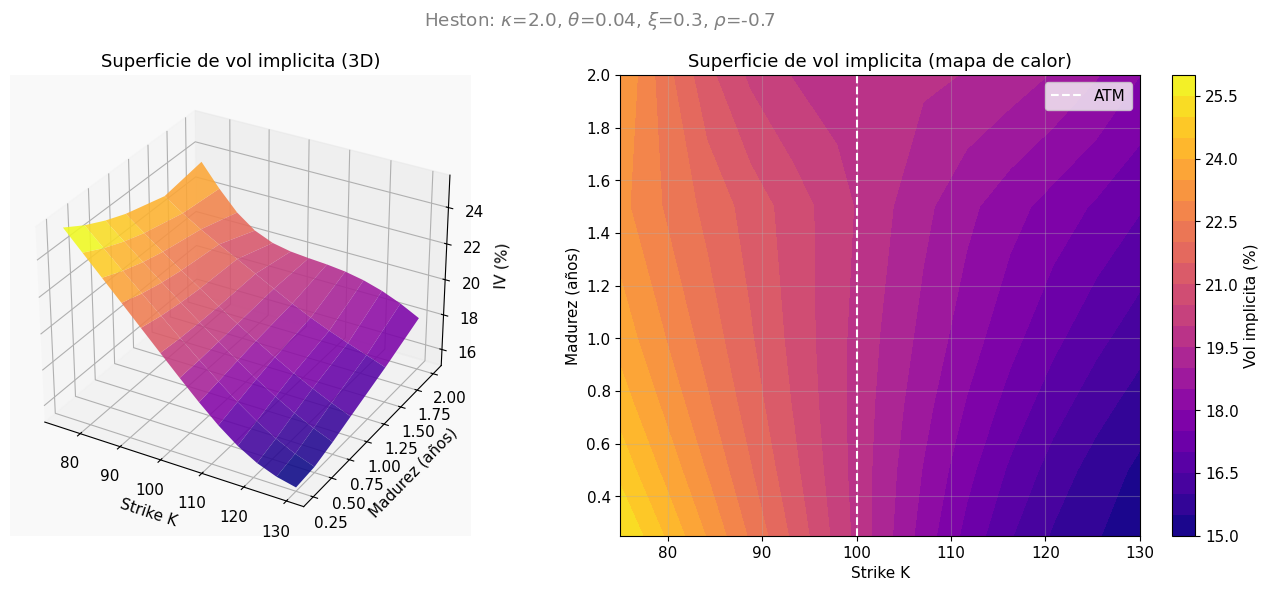

In [13]:
strikes_s = np.linspace(75, 130, 13)
taus_s    = np.array([0.25, 0.5, 0.75, 1.0, 1.5, 2.0])

print("Calculando superficie... (~30 segundos)")
IV = np.full((len(taus_s), len(strikes_s)), np.nan)
for i, t in enumerate(taus_s):
    for j, k in enumerate(strikes_s):
        p, _, _ = heston_call(S0, k, r, t, v0, kappa, theta, xi, rho)
        IV[i, j] = bs_implied_vol(p, S0, k, r, t) * 100
    print(rf"  $\tau$ = {t:.2f}a completado")

Kg, Tg = np.meshgrid(strikes_s, taus_s)

fig = plt.figure(figsize=(14, 6))

ax3 = fig.add_subplot(121, projection='3d')
ax3.plot_surface(Kg, Tg, IV, cmap='plasma', alpha=0.88, edgecolor='none')
ax3.set_xlabel('Strike K');  ax3.set_ylabel('Madurez (años)');  ax3.set_zlabel('IV (%)')
ax3.set_title('Superficie de vol implicita (3D)')

ax2 = fig.add_subplot(122)
im = ax2.contourf(Kg, Tg, IV, levels=20, cmap='plasma')
fig.colorbar(im, ax=ax2, label='Vol implicita (%)')
ax2.axvline(S0, color='white', ls='--', lw=1.5, label='ATM')
ax2.set_xlabel('Strike K');  ax2.set_ylabel('Madurez (años)')
ax2.set_title('Superficie de vol implicita (mapa de calor)');  ax2.legend()

plt.suptitle(rf'Heston: $\kappa$={kappa}, $\theta$={theta}, $\xi$={xi}, $\rho$={rho}', color='gray')
plt.tight_layout();  plt.show()


## 13. Resumen del flujo completo

Heston SDEs  ($S_t$, $v_t$)
       Feynman-Kac + forma propuesta  $\varphi = exp^{C + Dv + iux}$
Funcion caracteristica $\varphi_j(u, \tau)$   [forma cerrada, estable]
       Inversion de Fourier numerica
$P_1$, $P_2$   (probabilidades bajo dos medidas distintas)
       Sustitucion en la formula de Heston
$C = S  P_1 - K  e^{-r \tau}  P_2$

**Lo que Heston gana sobre B&S:**
- Genera una sonrisa/skew de vol implicita observable en el mercado.
- $\rho$ controla la pendiente;  $\xi$ controla la curvatura.


# Respuestas

## 1. Violación de Feller

Con los parámetros base ($\kappa=2.0$, $\theta=0.04$, $\xi=0.30$): $2\kappa\theta = 0.16 > \xi^2 = 0.09$, se cumple.

Para violarla, $\xi$ tendría que crecer hasta que $\xi^2 > 2\kappa\theta = 0.16$, es decir, $\xi > \sqrt{0.16} = 0.4$. Con $\xi=0.5$ o más, la condición se rompe.

**Consecuencia en la sonrisa:** $\xi$ controla la curvatura de la sonrisa. Al subir $\xi$ para violar Feller, la varianza fluctúa más, engordando ambas colas de la distribución de $\ln S_T$ y produciendo una sonrisa más pronunciada. $v_t$ puede entonces tocar cero ocasionalmente, pero esto no invalida el pricing por función característica; solo complica la simulación Monte Carlo, que necesita el esquema QE para evitar varianzas negativas.

## 2. $\rho = 0$

$\rho$ es la correlación instantánea entre los shocks de precio y de varianza. $\rho=0$ significa que son independientes.

**No es realista para acciones.** Existe el efecto leverage: cuando el precio cae, la volatilidad tiende a subir. Eso es correlación negativa, típicamente $\rho\in[-0.8,-0.5]$ para índices. Un $\rho=0$ elimina esa asimetría y predice una sonrisa simétrica, que no coincide con lo observado: los puts OTM son sistemáticamente más caros que los calls OTM equivalentes.

## 3. Función característica vs densidad

Ambas contienen la misma información, son transformada de Fourier una de la otra, pero no cuesta lo mismo extraerla. En Heston, $\varphi(u)$ tiene forma cerrada explícita. Para obtener $p(\mathbb{X})$ a partir de $\varphi$ habría que invertir la transformada, lo cual requiere una integral numérica sin forma cerrada. Trabajar con $p(\mathbb{X})$ directamente exigiría primero pagar ese costo de inversión y después integrar de nuevo contra el payoff: dos pasos numéricos. Trabajar con $\varphi(u)$ permite ir del objeto cerrado al precio en un solo paso, sin construir nunca la densidad.




## 4. La paradoja de $P_1, P_2$ más grandes pero precio menor

| Cantidad | B&S | Heston |
|---|---|---|
| $P_1$ / $\mathcal{N}(d_1)$ | 0.6368 | 0.6919 |
| $P_2$ / $\mathcal{N}(d_2)$ | 0.5596 | 0.6181 |
| Precio | 10.4506 | 10.3942 |

El precio no es la resta directa de $P_1$ y $P_2$; es $S\cdot P_1 - Ke^{-r\tau}\cdot P_2$, resta de dos términos que crecen de forma distinta:

- $S\cdot P_1$: B&S = 63.68, Heston = 69.19 (sube)
- $Ke^{-r\tau}\cdot P_2$: B&S = 53.23, Heston = 58.79 (sube más)

Ambos bloques suben en Heston, pero el que se resta sube más. La diferencia neta termina siendo menor aunque cada probabilidad individual sea mayor. Es aritmética de una resta, no una contradicción.

## 5. Si el modelo de varianza fuera cúbico en $v_t$

**No, dejaría de funcionar.** La forma propuesta $\varphi=e^{C+Dv+iux}$ funciona porque los coeficientes de la EDP de Heston son afines en $v$, así que al sustituir y agrupar, cada derivada trae como mucho una potencia de $D$ multiplicando a $\varphi$, y el resultado es polinomial de bajo grado en $v$, permitiendo igualar coeficientes por separado.

Si el modelo fuera cúbico en $v_t$, aparecerían términos $v^3\varphi$, $v^4\varphi$, que esta forma propuesta no puede generar. La igualación de coeficientes ya no cerraría en un sistema finito de ODEs; el modelo perdería la pertenencia a la clase afín (Duffie-Pan-Singleton, 2000).

**Lo que se pierde:** la tratabilidad analítica completa, no habría ODEs cerradas para $C,D$, no habría función característica cerrada, y el pricing tendría que hacerse por Monte Carlo o PDE numérica, perdiendo la velocidad que hace útil a Heston para calibración en tiempo real.
